> This notebook requires private benchmark data files that are not included in the public repository. See `../data/README.md` and `../labels/README.md`.


# Model Debugging & Alert Validation

This notebook runs the raw-RMS production path and validates the alert engine against labeled incidents.

**Prerequisites:** The setup below loads the fit/pred data, applies spike clipping, and keeps `uptime` as the only operational gating signal.

**Coverage:**
- Interactive scoring widget (per-scenario sigmoid + channel occupancy)
- Interactive API replay widget (full pipeline replay with alert decisions)
- Alert engine semantics and re-alert logic
- Single-scenario deep dive: per-batch occupancy, channel breakdown, debug views
- All-scenarios summary and debugging tables

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display, Markdown

from analysis.evaluation import assign_incident_label
from analysis.model_cache import fit_and_save, load_fitted_models
from analysis.plotting import (
    clear_sigmoid_scoring_caches,
    create_api_replay_widget,
    create_sigmoid_scoring_widget,
    set_plot_style,
)
from sample_processing.model.current.preprocessing import clip_rms_spikes
from sample_processing.model.current.anomaly_model import (
    load_model_params,
    load_pipeline_params,
)

from analysis.evaluation.reporting import md_table, plot_confusion

set_plot_style()

## Setup

Runs the raw-RMS preprocessing path used by the repository today: load fit/pred data, apply spike clipping, and trust `uptime=True` as the machine-operating gate. No Butterworth filtering or regime labeling is used here.

In [2]:
DATA_DIR    = Path("../data")
LABELS_PATH = Path("../labels/incidents.yaml")

In [3]:
# --- load incident windows ---------------------------------------------------
with open(LABELS_PATH) as f:
    _raw = yaml.safe_load(f)

# {scenario_id: [(start, end, incident_index), ...]}
_incidents: dict[int, list[tuple]] = {
    int(sid): [
        (pd.Timestamp(w["start"]), pd.Timestamp(w["end"]), i)
        for i, w in enumerate(windows, start=1)
    ]
    for sid, windows in _raw.items()
}

# --- load fit files (always healthy) ----------------------------------------
fit_frames = []
for path in sorted(DATA_DIR.glob("sensor_data_fit_*.parquet"), key=lambda p: int(p.stem.split("_")[-1])):
    scenario_id = int(path.stem.split("_")[-1])
    df = pd.read_parquet(path)
    df.insert(0, "scenario_id", scenario_id)
    df.insert(1, "split", "fit")
    df.insert(2, "label", "normal")
    fit_frames.append(df)

# --- load pred files (label rows against incident windows) ------------------
pred_frames = []
for path in sorted(DATA_DIR.glob("sensor_data_pred_*.parquet"), key=lambda p: int(p.stem.split("_")[-1])):
    scenario_id = int(path.stem.split("_")[-1])
    df = pd.read_parquet(path)
    df.insert(0, "scenario_id", scenario_id)
    df.insert(1, "split", "pred")
    windows = _incidents.get(scenario_id, [])
    df.insert(2, "label", df["sampled_at"].apply(lambda ts: assign_incident_label(ts, windows)))
    pred_frames.append(df)

# --- combine -----------------------------------------------------------------
full_df = (
    pd.concat(fit_frames + pred_frames, ignore_index=True)
    .sort_values(["scenario_id", "sampled_at"])
    .reset_index(drop=True)
)

full_df = clip_rms_spikes(full_df, vel_threshold=100, accel_threshold=10)


## 1. Hyperparameter Loading

Reads model, pipeline, and alert parameters from the YAML files under `src/sample_processing/model/current/hyperparameters/ (model + alert) and src/sample_processing/model/shared/ (pipeline)`. These drive the scoring thresholds, sliding window configuration, and alert engine behaviour used throughout this notebook.

In [4]:
model_params    = load_model_params()
pipeline_params = load_pipeline_params()

FUSION_THRESHOLD      = model_params.fusion_threshold
WINDOW_SIZE_HOURS     = pipeline_params.model_window_size_hours
WINDOW_OVERLAP_HOURS  = pipeline_params.window_overlap_hours

print(f"window={WINDOW_SIZE_HOURS}h  overlap={WINDOW_OVERLAP_HOURS}h")
print(f"fusion_threshold={FUSION_THRESHOLD}")

window=2.0h  overlap=1.0h
fusion_threshold=0.5


## 2. Fit and Freeze

Fits all 29 per-scenario models using the per-group hyperparameters calibrated in `01_eda.ipynb` and caches them to `cache/models/v{N}/`. Re-run any time a fit-affecting hyperparameter changes in `norm_model_hyperparams.yaml` (alpha, beta, thresholds, window_top_k, fusion_threshold). The cache keeps a version history so this notebook, the API container, and the inference test all pick up the same frozen weights.

In [5]:
# Fit all 29 scenarios and write to cache/models/v{N}/.
# Set manual_version to an integer (for example 1, 2, 3) to save or replace that exact folder.
# Leave it as None to auto-increment to the next free version.

version = fit_and_save(version=1, notes="")
print(f"Saved version {version}")

Fitting 29 scenarios -> v1 ...
  fitted scenario 1
  fitted scenario 2
  fitted scenario 3
  fitted scenario 4
  fitted scenario 5
  fitted scenario 6
  fitted scenario 7
  fitted scenario 8
  fitted scenario 9
  fitted scenario 10
  fitted scenario 11
  fitted scenario 12
  fitted scenario 13
  fitted scenario 14
  fitted scenario 15
  fitted scenario 16
  fitted scenario 17
  fitted scenario 18
  fitted scenario 19
  fitted scenario 20
  fitted scenario 21
  fitted scenario 22
  fitted scenario 23
  fitted scenario 24
  fitted scenario 25
  fitted scenario 26
  fitted scenario 27
  fitted scenario 28
  fitted scenario 29
Saved to cache/models/v1  (29 models)
Saved version 1


In [6]:
# Load pre-fitted models for the replay widget
version_to_load = version if "version" in locals() else "latest"
fitted_models, model_meta = load_fitted_models(version=version_to_load)

print("loaded version:", model_meta["version"])
print("baseline_scaler:", model_meta["baseline_scaler"])
print("created_at:", model_meta["created_at"])
if model_meta["notes"]:
    print("notes:", model_meta["notes"])

Loaded v1: 29 models  (2026-06-12T21:55:48)
loaded version: 1
baseline_scaler: standard
created_at: 2026-06-12T21:55:48.745747+00:00


## 3. Interactive Scoring Widget

Uses `create_sigmoid_scoring_widget` to inspect per-scenario scoring with the per-group sigmoid parameters, plus channel occupancy and active modality attribution (payload prep is cached). Select a scenario and signal channel from the dropdowns, then click **Plot**.

The 7-row figure shows, top to bottom: raw time series, residuals (`d_*`), sigmoid scores, per-channel occupancy, per-modality max occupancy, fusion score, and the active modality per window. This is the primary debugging tool for per-scenario tuning - the residual panel tells us whether the model is seeing the event, and the occupancy and fusion panels tell us whether the engine will react to it.

> **Scenarios worth a close look:** 6, 27 (both `group_2`) and 7, 29 (`group_1` and `group_3`) are the current limitations. Use this widget to inspect their residual and occupancy trajectories before reading the failure analysis at the end of the notebook.

In [7]:
clear_sigmoid_scoring_caches()

scoring_widget = create_sigmoid_scoring_widget(full_df=full_df)
display(scoring_widget)

## 4. Alert Hierarchy And Suppression Rules

The alert engine uses a strict priority order so we do not emit redundant alarms while the failure signature is escalating:

| Priority | Event scope | Trigger | Suppresses | Confirmation / release |
|---|---|---|---|---|
| 0 (low) | Individual channel open / re-alert | A single causal channel confirms and worsens enough | Nothing higher is active yet | 3-of-4 per-channel confirmation + cooldown |
| 1 (medium) | `group-3` open / re-alert | All 3 channels of one modality (vel or accel) are active and grouped severity worsens | Individual opens and re-alerts | 2-of-3 grouped confirmation; lower-priority events are held while grouped escalation is being resolved |
| 2 (high) | `group-6` open / re-alert | Velocity and acceleration signatures are both active and the full degradation pattern confirms | `group-3` plus individual events | Highest priority; pending lower-priority events are dropped once this confirms |

> **Status of `group-6`.** The group-6 tier is implemented but disabled in `alert_hyperparams.yaml` (`enable_group6_alerts: false`). With the current dataset, enabling it hurts aggregate recall - group-6 confirmation is slower than group-3 and the incident windows are short enough that the group-3 path already wins. The tier is retained in the code so it can be turned on for longer-horizon deployments without re-architecting the engine.

### Practical Semantics

- The engine always prefers the highest-priority event available in the current escalation path.
- Lower-priority alarms can be held in a pending state instead of emitted immediately (`pending_priority_events`).
- A pending event is only released after the higher-priority confirmation opportunity has fully expired, or the anomaly de-escalates.
- While a grouped mode is active, we keep channel ownership attached to the grouped episode so a lower-priority reopen does not appear in the middle of escalation.
- `individual_alert_mode="exclusive"` means a single-channel case owns the episode until it resets; a second channel's open is queued rather than emitted, preventing parallel-alarm noise.
- Scenario 3 is the reference case for this behavior: accel opens first, then the grouped accel pattern takes over, and finally the full 6-channel degradation would win once `enable_group6_alerts` is on.

### Visual Companion

The figures below are conceptual diagrams used to explain the alert hierarchy logic and ownership handoff.

They are not intended to be an exact visualization of `full_df` or a batch-by-batch replay output, but to illustrate the approach.


### Alert hierarchy reference

![Alert hierarchy demo](assets/alert_hierarchy/alert-hierarchy-demo.svg)

The maintained local HTML source is available at [assets/alert_hierarchy/alert-hierarchy-demo.html](assets/alert_hierarchy/alert-hierarchy-demo.html).


## 5. API Replay Widget

Replays the scoring + alert engine on each scenario as if the API had been called in production. The widget below lets you select a scenario and walk through the emitted alerts alongside the fusion score and channel occupancy.

In [8]:
ui, _ = create_api_replay_widget(
    full_df=full_df,
    scenario_col="scenario_id",
    split_col="split",
    fit_value="fit",
    pred_value="pred",
    time_col="sampled_at",
    label_col="label",
    normal_label="normal",
    default_x_axis="Time",
    models=fitted_models,
)
display(ui)


## 6. Evaluation Against `src/tests/test_evaluation.py`

Runs the full fit â†’ batched-predict pipeline through the FastAPI `/fit` + `/predict` endpoints â€” the exact path used in production and by the test suite (2-hour outer window, 1-hour stride), with no offline shortcut. 

In [ ]:
from analysis.evaluation import run_inference_test_evaluation
report = run_inference_test_evaluation(full_df=full_df)

This evaluation calls the same FastAPI path the production API and `src/tests/test_evaluation.py` use, so the numbers below match the test gate exactly. It takes about 14 minutes. Everything shown is generated directly from the returned `report`, so it never goes stale.

**Two ways to score the same run:**

- **Per-machine** (one row per scenario) â€” a scenario is a *hit* if at least one alert lands in any of its incident windows, even when it has two incidents and only one was caught (a `PARTIAL`). Answers: *would we flag this machine?*
- **Per-event** (one row per labeled fault window) â€” each fault window is scored on its own, so a `PARTIAL` scenario contributes one hit (TP) **and** one miss (FN). Answers: *of all the real fault events, how many did we catch?*

Per-machine recall is the headline gate; per-event recall is stricter and exposes the PARTIALs. The per-scenario `status` column uses the pytest semantics: `TN`, `FP`, `TP`, `PARTIAL`, `FN`.

### 6.1 Per-machine results

Each scenario is one instance, regardless of how many fault windows it contains. A `PARTIAL` scenario (at least one window caught, but not all) still counts as a true positive â€” this answers *"would we flag this machine for inspection?"*

These precision/recall/F1 values are the scenario-level aggregate metrics mirrored by `src/tests/test_evaluation.py`; the notebook table is value-only.

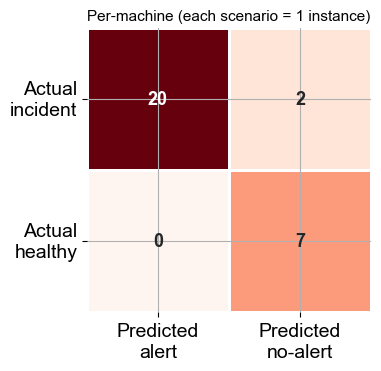

| metric | value | formula |
| --- | --- | --- |
| precision | 1.0 | TP / (TP + FP) |
| recall | 0.909 | TP / (TP + FN) |
| f1 | 0.952 | 2PR / (P + R) |
| alert_efficiency | 0.793 | covered / n_alerts |

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(ax, report["confusion_matrix_df"], "Per-machine (each scenario = 1 instance)")
plt.tight_layout()
plt.show()
md_table(report["metric_cards_df"])

### 6.2 Per-event results

Each labeled fault window is one instance. A `PARTIAL` scenario with two fault windows contributes one TP and one FN â€” this answers *"of all the real fault events, how many did we catch?"*

Per-event recall is stricter than per-machine: scenarios **7** and **29** are `PARTIAL` (one of two windows missed each), so they count as full TPs at the per-machine level but each contributes one FN at the per-event level.

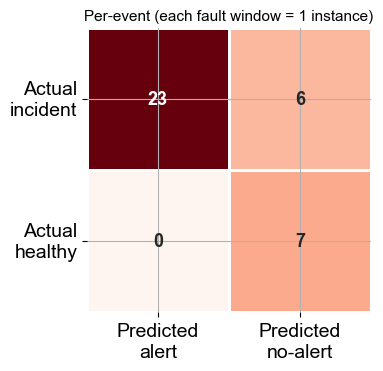

| metric | value | formula |
| --- | --- | --- |
| precision | 1.0 | TP / (TP + FP) |
| recall | 0.793 | TP / (TP + FN) |
| f1 | 0.885 | 2PR / (P + R) |

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(ax, report["window_confusion_matrix_df"], "Per-event (each fault window = 1 instance)")
plt.tight_layout()
plt.show()
md_table(report["window_metric_cards_df"])

### 6.3 Per-test-type breakdown

Mirrors the parametrization in `src/tests/test_evaluation.py`. `test_every_incident_window_gets_an_alert` is the only test that separates `PARTIAL` from `TP` â€” it fails for scenarios 7 and 29 while the looser `test_at_least_one_alert_in_any_incident_window_multi` passes.

In [ ]:
md_table(report["per_test_df"])

| test | parametrization | passed | failed | failing_scenarios |
| --- | --- | --- | --- | --- |
| test_no_alert_when_no_incident | 7 scenarios | 7 | 0 | - |
| test_alert_fires_in_incident_window_single | 15 scenarios | 15 | 0 | - |
| test_at_least_one_alert_in_any_incident_window_multi | 7 scenarios | 5 | 2 | 6, 27 |
| test_every_incident_window_gets_an_alert | 7 scenarios | 3 | 4 | 6, 7, 27, 29 |

#### Per-machine drill-down

One row per scenario. `covered_incident_count` and `missed_incident_count` are per-event counts within each scenario.

In [ ]:
display(report["scenario_coverage_df"])

,scenario_id,scenario_group,scenario_group_label,status,n_incidents,covered_incident_count,missed_incident_count,n_alerts,alert_efficiency,has_alert_in_window,all_incident_windows_hit
0,1,group_1,Group 1 - large single spike,TP,1,1,0,1,1.000,True,True
1,2,group_1,Group 1 - large single spike,TP,1,1,0,1,1.000,True,True
2,3,group_2,Group 2 - sudden trend increase,TP,1,1,0,1,1.000,True,True
3,4,group_1,Group 1 - large single spike,TP,2,2,0,7,0.286,True,True
4,5,group_3,Group 3 - segments with sudden increases and b...,TP,2,2,0,2,1.000,True,True
5,6,group_2,Group 2 - sudden trend increase,FN,2,0,2,0,0.000,False,False
6,7,group_1,Group 1 - large single spike,PARTIAL,2,1,1,1,1.000,True,False
7,8,group_3,Group 3 - segments with sudden increases and b...,TP,1,1,0,2,0.500,True,True
8,9,group_1,Group 1 - large single spike,TP,1,1,0,1,1.000,True,True
9,10,group_2,Group 2 - sudden trend increase,TP,1,1,0,1,1.000,True,True


#### Blocking scenarios

The `FN` and `PARTIAL` machines that still need work â€” these are the scenarios that block full test coverage.

In [ ]:
display(report["blocking_scenarios_df"])

,scenario_id,scenario_group,scenario_group_label,status,n_incidents,covered_incident_count,missed_incident_count,n_alerts,alert_efficiency,has_alert_in_window,all_incident_windows_hit
0,6,group_2,Group 2 - sudden trend increase,FN,2,0,2,0,0.0,False,False
1,27,group_2,Group 2 - sudden trend increase,FN,2,0,2,0,0.0,False,False
2,7,group_1,Group 1 - large single spike,PARTIAL,2,1,1,1,1.0,True,False
3,29,group_3,Group 3 - segments with sudden increases and b...,PARTIAL,2,1,1,1,1.0,True,False


In [ ]:
report["best_group_reassignments_df"]

,scenario_id,current_group,current_group_label,candidate_group,candidate_group_label,current_status,candidate_status,current_n_alerts,candidate_n_alerts,current_covered_incident_count,...,current_missed_incident_count,candidate_missed_incident_count,current_has_alert_in_window,candidate_has_alert_in_window,current_all_incident_windows_hit,candidate_all_incident_windows_hit,delta_n_alerts,comparison_outcome,strictly_better,not_worse
4,27,group_2,Group 2 - sudden trend increase,group_3,Group 3 - segments with sudden increases and b...,FN,FN,0,0,0,...,2,2,False,False,False,False,0,marginal,False,True


In [ ]:
display(report["worst_scenarios_df"])

,scenario_id,scenario_group,scenario_group_label,n_incidents,n_alerts,alerts,incident_windows,has_alert_in_window,covered_incident_count,covered_incident_windows,missed_incident_count,missed_incident_windows,all_incident_windows_hit,status,alert_efficiency
0,6,group_2,Group 2 - sudden trend increase,2,0,[],"[{'start': '2026-02-24T16:00:00+00:00', 'end':...",False,0,[],2,"[{'start': '2026-02-24T16:00:00+00:00', 'end':...",False,FN,0.000
1,27,group_2,Group 2 - sudden trend increase,2,0,[],"[{'start': '2026-02-27T11:15:00+00:00', 'end':...",False,0,[],2,"[{'start': '2026-02-27T11:15:00+00:00', 'end':...",False,FN,0.000
2,7,group_1,Group 1 - large single spike,2,1,[2026-02-27T15:57:02+00:00],"[{'start': '2026-02-21T15:00:00+00:00', 'end':...",True,1,"[{'start': '2026-02-27T12:00:00+00:00', 'end':...",1,"[{'start': '2026-02-21T15:00:00+00:00', 'end':...",False,PARTIAL,1.000
3,29,group_3,Group 3 - segments with sudden increases and b...,2,1,[2026-02-25T23:11:03+00:00],"[{'start': '2026-02-25T11:30:00+00:00', 'end':...",True,1,"[{'start': '2026-02-25T11:30:00+00:00', 'end':...",1,"[{'start': '2026-03-04T05:00:00+00:00', 'end':...",False,PARTIAL,1.000
4,4,group_1,Group 1 - large single spike,2,7,"[2026-01-22T13:06:02+00:00, 2026-01-30T02:06:0...","[{'start': '2026-02-04T16:00:00+00:00', 'end':...",True,2,"[{'start': '2026-02-04T16:00:00+00:00', 'end':...",0,[],True,TP,0.286


### Failure Analysis - Scenario 6 - `FN` (2 windows, 0 alerts)

- Visually, there is no indication in the signal that either window contains the egregious baseline deviation, but the deviation does appear between the two windows. Because of that, I do not think this case is as bad as it seems.

<table>
  <tr>
    <td><img src="_generated/widget_exports/sigmoid_scoring/scenario_6.png" alt="Scenario 1" width="100%"></td>
    <td><img src="_generated/widget_exports/api_replay/scenario_6.png" alt="Scenario 2" width="100%"></td>
  </tr>
</table>



### Failure Analysis - Scenario 7 - `PARTIAL` (2 windows, 1 alert)

- This error was caused by the anomaly detection approach being tuned for large signal deviations, not for this change in behavior where the apparent ON-OFF pattern stops and we only have ON. This could likely be corrected with a model specialized for this kind of detection competing with the current approach to assign the label.

- I previously tested better calibration, but it caused the other scenarios in the group to become wrong.

<table>
  <tr>
    <td><img src="_generated/widget_exports/sigmoid_scoring/scenario_7.png" alt="Scenario 1" width="100%"></td>
    <td><img src="_generated/widget_exports/api_replay/scenario_7.png" alt="Scenario 2" width="100%"></td>
  </tr>
</table>



### Failure Analysis - Scenario 27 - `FN` (2 windows, 0 alerts)

- The same error seen in Scenario 6 happened here. The model detected the large amplitude in the middle of the two windows. The approach was not capable of detecting it within the windows, only between them, so the error is not as egregious.

<table>
  <tr>
    <td><img src="_generated/widget_exports/sigmoid_scoring/scenario_27.png" alt="Scenario 1" width="100%"></td>
    <td><img src="_generated/widget_exports/api_replay/scenario_27.png" alt="Scenario 2" width="100%"></td>
  </tr>
</table>



### Failure Analysis - Scenario 29 - `PARTIAL` (2 windows, 1 alert)

- The error here is very similar to Scenario 7. The ON-OFF behavior made it difficult to detect the second window, so a more specialized model would likely improve this.

<table>
  <tr>
    <td><img src="_generated/widget_exports/sigmoid_scoring/scenario_29.png" alt="Scenario 1" width="100%"></td>
    <td><img src="_generated/widget_exports/api_replay/scenario_29.png" alt="Scenario 2" width="100%"></td>
  </tr>
</table>



### Failure Analysis - Scenario 4 - Too many alarms - 2 windows and 7 alerts

- This is the only case of excessive alarms that appeared in this work. This can be corrected with changes in the reset flags so it doesn't reset as fast. This can be tuned later on. 

<table>
  <tr>
    <td><img src="_generated/widget_exports/sigmoid_scoring/scenario_4.png" alt="Scenario 1" width="100%"></td>
    <td><img src="_generated/widget_exports/api_replay/scenario_4.png" alt="Scenario 2" width="100%"></td>
  </tr>
</table>

In [ ]:
from analysis.evaluation import diagnose_group_reassignment

scenario_4_reassignment_df = diagnose_group_reassignment(4, full_df=full_df)

## Final Error Report

- Two of the four scenario errors (7, 29) are not as severe in timing terms, since the signals at the incident labels are actually low compared with the large spikes in the middle.
- Scenarios 6 and 27 would benefit from a more specialized model to detect their specific case.
- The current model is very good for what it is trying to accomplish, and I do not believe better alert calibration would solve these four errors. Specialized models would.

## 7. MLflow Comparison: Baseline vs Current

Logs two parent runs to the SQLite tracking store at `mlflow.db` (repo root) under the experiment `"baseline-vs-current"`:

- **baseline** â€” velocity-only L2-norm detector evaluated directly (no API layer)
- **current** â€” 6-channel sigmoid model evaluated through the FastAPI test client

Each run contains global metrics (precision / recall / F1), per-test-type pass/fail counts, and a 29-scenario coverage table artifact.

After this cell completes, view both runs side-by-side with the command in the last cell:

    mlflow ui --backend-store-uri sqlite:///mlflow.db

In [ ]:
from analysis.mlflow_experiments import compare_baseline_vs_current

results = compare_baseline_vs_current()

c:\Users\arthu\anaconda3\envs\IRV_env\Lib\site-packages\pydantic\_internal\_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Evaluating baseline model ...


KeyboardInterrupt: 

In [ ]:
_metrics = ["precision", "recall", "f1", "tp", "fp", "fn", "tn"]
pd.DataFrame([
    {"model": "baseline", **{k: results["baseline_report"]["summary"][k] for k in _metrics}},
    {"model": "current",  **{k: results["current_report"]["summary"][k] for k in _metrics}},
]).set_index("model").round(3)

,precision,recall,f1,tp,fp,fn,tn
model,,,,,,,
baseline,0.286,0.273,0.279,6,4,16,3
current,1.000,0.909,0.952,20,0,2,7


mlflow ui --backend-store-uri sqlite:///mlflow.db